What I want to do:
- I want to have a held out 30% of data (which right now is in val and test, but we will treat it all as my testing data because else it is very scary)
- I want to then do a little k-fold
- within each fold I want to train with my preprocessing
- use some sort of select from model for feature selection
- then train my NN
- Use ray tune to do hyperparameter tuning
- I think I will chunk the tuning into three categories
  1. preprocessing hyperparameters (they seem relevant)
  2. feature selection (kinda just in general, like which model y'know)
  3. NN hyperparmeters (but also just like general additions I could possibly add, but that comes later)

In [9]:
# Imports
import os
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import pickle
import numpy as np
# from statistics import mean, stdev
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RepeatedStratifiedKFold
from itertools import product
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix
)
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
import numpy as np
import torch, random, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import config
from preprocessing_utils import *
from model_utils import *

# Set seeds for reproducibility
set_random_seed(config.SEED, deterministic=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
class MultimodalDataset(Dataset):
    def __init__(self, X, y, clinical_cols, mrna_cols, mutation_cols):
        # Split modalities
        self.clinical = X[clinical_cols].to_numpy()
        self.mrna = X[mrna_cols].to_numpy().astype(float)
        self.mutation = X[mutation_cols].to_numpy().astype(float)
        self.labels = y.to_numpy().astype(float)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

In [11]:
X_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_train.joblib"))
y_train = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_train.joblib"))
X_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_val.joblib"))
y_val = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_val.joblib"))
X_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "X_test.joblib"))
y_test = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "y_test.joblib"))
clinical_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "clinical_cols.joblib"))
mrna_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mrna_cols.joblib"))
mutation_cols = joblib.load(os.path.join(config.SPLIT_DATA_DIR, "mutation_cols.joblib"))

X_testval = pd.concat([X_val, X_test], axis=0).reset_index(drop=True)
y_testval = pd.concat([y_val, y_test], axis=0).reset_index(drop=True)

# Split modalities
clinical_train = X_train[clinical_cols]
mrna_train = X_train[mrna_cols]
mutation_train = X_train[mutation_cols]

clinical_val = X_val[clinical_cols]
mrna_val = X_val[mrna_cols]
mutation_val = X_val[mutation_cols]

clinical_test = X_test[clinical_cols]
mrna_test = X_test[mrna_cols]
mutation_test = X_test[mutation_cols]

clinical_testval = X_testval[clinical_cols]
mrna_testval = X_testval[mrna_cols]
mutation_testval = X_testval[mutation_cols]

In [12]:
def to_loader(c, m, mu, y, shuffle=False):
    
    def check_numeric(df, name):
        if isinstance(df, np.ndarray):
            df = pd.DataFrame(df)
        non_numeric_cols = []
        for col in df.columns:
            if not pd.api.types.is_numeric_dtype(df[col]):
                non_numeric_cols.append(col)
        if non_numeric_cols:
            print(f"WARNING: {name} has non-numeric columns: {non_numeric_cols}")
            # Print the first few rows of problematic columns
            print(df[non_numeric_cols].head())
        return df.to_numpy(dtype=np.float32)
    
    c = check_numeric(c, "Clinical")
    m = check_numeric(m, "mRNA")
    mu = check_numeric(mu, "Mutation")

    if isinstance(y, (pd.DataFrame, pd.Series)):
        y = y.to_numpy(dtype=np.float32).reshape(-1, 1)
    else:
        y = np.array(y, dtype=np.float32).reshape(-1, 1)
    y = y.squeeze() # converts from [x, 1] to [x] shape

    ds = TensorDataset(
        torch.tensor(c),
        torch.tensor(m),
        torch.tensor(mu),
        torch.tensor(y)
    )
    return DataLoader(ds, batch_size=config.BATCH_SIZE, shuffle=shuffle)


In [13]:
# =======================
# Neural Network
# =======================
class MultimodalNet(nn.Module):
    def __init__(self,
                 clin_dim, mrna_dim, mut_dim,
                 clin_hidden=[64, 32],
                 mrna_hidden=[64, 32],
                 mut_hidden=[64, 32],
                 clin_dropout=[0, 0],
                 mrna_dropout=[0, 0],
                 mut_dropout=[0, 0],
                 activation='relu',
                 fusion_hidden=64,
                 fusion_dropout=0,
                 use_gene_sel=True,
                ):
        super().__init__()
        
        self.use_gene_sel = use_gene_sel
        if use_gene_sel:
            # ===== Gene selectors (for omics modalities) =====
            self.gene_sel_mrna = GeneSelector(mrna_dim)
            self.gene_sel_mut = GeneSelector(mut_dim)

        # ===== Modality encoders =====
        self.enc_clin = ModalityEncoder(clin_dim, clin_hidden, clin_dropout, activation)
        self.enc_mrna = ModalityEncoder(mrna_dim, mrna_hidden, mrna_dropout, activation)
        self.enc_mut  = ModalityEncoder(mut_dim, mut_hidden, mut_dropout, activation)


        # ===== Fusion + final classifier =====
        total_dim = clin_hidden[-1] + mrna_hidden[-1] + mut_hidden[-1]
        self.fusion_fc = nn.Sequential(
            nn.Linear(total_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(fusion_dropout),
            nn.Linear(fusion_hidden, 1)
        )
        
    def forward(self, clin, mrna, mut):
        if self.use_gene_sel:
            # Apply gene selectors
            mrna = self.gene_sel_mrna(mrna)
            mut = self.gene_sel_mut(mut)

        # Encode each modality
        clin_emb = self.enc_clin(clin)
        mrna_emb = self.enc_mrna(mrna)
        mut_emb  = self.enc_mut(mut)
        
        # Fuse and classify
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()



In [14]:
def train_one_fold(train_loader, val_loader, model, optimizer, criterion, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    best_val_auroc, best_state, patience_counter = 0, None, 0

    for epoch in range(config.NUM_EPOCHS):
        model.train()
        for clin, mrna, mut, y in train_loader:
            clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(clin, mrna, mut)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for clin, mrna, mut, y in val_loader:
                clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
                probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
                all_probs.append(probs)
                all_labels.append(y.cpu().numpy())

        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        val_auroc = roc_auc_score(all_labels, all_probs)

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= config.PATIENCE:
                break

    return best_state

def evaluate_with_threshold(model, loader, threshold):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clin, mrna, mut, y in loader:
            clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
            probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = (all_probs >= threshold).astype(float)

    metrics = {
        'auroc': roc_auc_score(all_labels, all_probs),
        'auprc': average_precision_score(all_labels, all_probs),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall': recall_score(all_labels, preds, zero_division=0),
        'f1': f1_score(all_labels, preds, zero_division=0)
    }
    return metrics


def run_kfold_gridsearch_with_preprocessing(
    clinical_df, mrna_df, mutation_df, labels,
    external_clinical_df, external_mrna_df, external_mutation_df, external_labels,
    param_grid,
    k=5,
    n_repeats=3,
    optimize_metric='f1',
):
    """
    Grid search with repeated stratified K-fold CV, fitting preprocessors and
    feature selectors (SelectFromModel) within each fold.
    """

    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=config.SEED)
    indices = np.arange(len(labels))
    param_combinations = list(product(*param_grid.values()))
    best_hyperparams, best_score = None, -1
    results_summary = {}

    for params in param_combinations:
        param_dict = dict(zip(param_grid.keys(), params))
        print(f"\n===== Hyperparams: {param_dict} =====")

        fold_metrics = {'auroc': [], 'auprc': [], 'precision': [], 'recall': [], 'f1': []}
        external_metrics = {'auroc': [], 'auprc': [], 'precision': [], 'recall': [], 'f1': []}

        for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
            print(f"\n--- Fold {fold + 1}/{k} ---")

            clin_train, clin_val = clinical_df.iloc[train_idx], clinical_df.iloc[val_idx]
            mrna_train, mrna_val = mrna_df.iloc[train_idx], mrna_df.iloc[val_idx]
            mut_train, mut_val = mutation_df.iloc[train_idx], mutation_df.iloc[val_idx]
            y_train, y_val = labels.iloc[train_idx], labels.iloc[val_idx]

            clinical_prep = ClinicalPreprocessorWrapper(
                cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
                categorical_cols=config.CATEGORICAL_COLS,
                max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
                uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
            )
            mrna_prep = MrnaPreprocessorWrapper(
                max_null_frac=config.MAX_NULL_FRAC,
                uniform_thresh=config.UNIFORM_THRESHOLD,
                random_state=config.SEED,
            )
            mutation_prep = MutationPreprocessorWrapper(
                max_mutation_count=param_dict["max_mutation_count"],
                uniform_thresh=param_dict["mutation_uniform_thresh"],
            )

            clinical_prep.fit(clin_train)
            mrna_prep.fit(mrna_train, y_train)
            mutation_prep.fit(mut_train)

            clin_train = clinical_prep.transform(clin_train)
            clin_val = clinical_prep.transform(clin_val)
            clin_ext = clinical_prep.transform(external_clinical_df.copy())

            mrna_train = mrna_prep.transform(mrna_train)
            mrna_val = mrna_prep.transform(mrna_val)
            mrna_ext = mrna_prep.transform(external_mrna_df.copy())

            mut_train = mutation_prep.transform(mut_train)
            mut_val = mutation_prep.transform(mut_val)
            mut_ext = mutation_prep.transform(external_mutation_df.copy())

            # === SelectFromModel for mRNA ===
            mrna_model_cls = param_dict["mrna_model"]  # e.g., LogisticRegression, RandomForestClassifier
            mrna_model_params = param_dict.get("mrna_model_params", {})  # estimator hyperparameters
            
            # If using XGBClassifier, inject safe/effective defaults for SelectFromModel
            if mrna_model_cls is XGBClassifier:
                # ensure importance_type is gain so feature_importances_ is meaningful
                mrna_model_params = {
                    **mrna_model_params,
                    "importance_type": "gain",
                    "use_label_encoder": False,
                    "eval_metric": "logloss",
                    "random_state": config.SEED,
                }
            
            sfm_mrna = SelectFromModel(
                estimator=mrna_model_cls(**mrna_model_params),
                threshold=param_dict.get("mrna_threshold", "median"),
                max_features=param_dict.get("mrna_max_features", None)
            )
            
            sfm_mrna.fit(mrna_train, y_train)
            mrna_train = sfm_mrna.transform(mrna_train)
            mrna_val   = sfm_mrna.transform(mrna_val)
            mrna_ext   = sfm_mrna.transform(mrna_ext)
            
            
            # === SelectFromModel for mutation ===
            mut_model_cls = param_dict["mut_model"]
            mut_model_params = param_dict.get("mut_model_params", {})
            
            if mut_model_cls is XGBClassifier:
                mut_model_params = {
                    **mut_model_params,
                    "importance_type": "gain",
                    "use_label_encoder": False,
                    "eval_metric": "logloss",
                    "random_state": config.SEED,
                }
            
            sfm_mut = SelectFromModel(
                estimator=mut_model_cls(**mut_model_params),
                threshold=param_dict.get("mut_threshold", "median"),
                max_features=param_dict.get("mut_max_features", None)
            )
            
            sfm_mut.fit(mut_train, y_train)
            mut_train = sfm_mut.transform(mut_train)
            mut_val   = sfm_mut.transform(mut_val)
            mut_ext   = sfm_mut.transform(mut_ext)

            # --- Build datasets and dataloaders ---
            train_loader = to_loader(clin_train, mrna_train, mut_train, y_train, shuffle=True)
            val_loader = to_loader(clin_val, mrna_val, mut_val, y_val)
            ext_loader = to_loader(clin_ext, mrna_ext, mut_ext, external_labels)

            model = SimpleMultimodalNet(clin_train.shape[1], mrna_train.shape[1], mut_train.shape[1],
                                        param_dict["hidden_dim"], param_dict["dropout"], param_dict["lr"]).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=param_dict.get('lr', 1e-3))
            pos_weight_value = torch.tensor((len(y_train) - y_train.sum()) / y_train.sum(), dtype=torch.float32).to(device)
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

            best_state = train_one_fold(train_loader, val_loader, model, optimizer, criterion, config.SEED + fold)
            model.load_state_dict(best_state)

            # Threshold tuning, evaluation identical
            all_probs, all_labels = [], []
            with torch.no_grad():
                for clin, mrna, mut, y in val_loader:
                    clin, mrna, mut, y = clin.to(device), mrna.to(device), mut.to(device), y.to(device)
                    probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
                    all_probs.append(probs)
                    all_labels.append(y.cpu().numpy())
            all_probs = np.concatenate(all_probs)
            all_labels = np.concatenate(all_labels)

            thresholds = np.linspace(0.001, 0.9, 200)
            best_t, best_metric = 0.5, -1
            for t in thresholds:
                preds = (all_probs >= t).astype(float)
                score = f1_score(all_labels, preds, zero_division=0)
                if score > best_metric:
                    best_metric, best_t = score, t

            val_metrics = evaluate_with_threshold(model, val_loader, best_t)
            ext_metrics = evaluate_with_threshold(model, ext_loader, best_t)

            print(f"Val metrics: {val_metrics}")
            print(f"Ext metrics: {ext_metrics}")

            for k_ in fold_metrics.keys():
                fold_metrics[k_].append(val_metrics[k_])
                external_metrics[k_].append(ext_metrics[k_])

        results_summary[str(param_dict)] = {
            "internal": {k: (mean(v), stdev(v)) for k, v in fold_metrics.items()},
            "external": {k: (mean(v), stdev(v)) for k, v in external_metrics.items()}
        }

        mean_f1 = results_summary[str(param_dict)]["internal"]["f1"][0]
        if mean_f1 > best_score:
            best_score = mean_f1
            best_hyperparams = param_dict

    print(f"\n=== Best hyperparameters: {best_hyperparams} (mean F1 = {best_score:.4f}) ===")
    return results_summary, best_hyperparams


In [15]:
def print_results_summary(results_summary):
    """
    Nicely prints the results summary from the k-fold grid search.
    """
    for param_str, metrics in results_summary.items():
        print("="*60)
        print(f"Hyperparameters: {param_str}")
        print("-"*60)
        for phase in ["internal", "external"]:
            print(f"{phase.upper()} METRICS:")
            for metric, (mean_val, std_val) in metrics[phase].items():
                print(f"  {metric:10}: {mean_val:.4f} ± {std_val:.4f}")
        print("="*60 + "\n")

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


#### XGBoost PARAM_GRID ###################################################################
param_grid = {
    # Models for mRNA
    "mrna_model": [
        XGBClassifier,
    ],

    # Hyperparameters for each mRNA model (small set so it runs quickly)
    "mrna_model_params": [
        {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.9},
    ],

    # Thresholds for mRNA selection
    "mrna_threshold": ["median"],
    "mrna_max_features": [None],

    # Models for mutation
    "mut_model": [
        XGBClassifier,
    ],

    # Hyperparameters for each mutation model
    "mut_model_params": [
        {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.9},
    ],

    # Thresholds for mutation selection
    "mut_threshold": ["median"],
    "mut_max_features": [None],

    # NN hyperparameters
    "hidden_dim": [64],
    "dropout": [0.2],
    "lr": [1e-3],
    "max_mutation_count": [1],
    "mutation_uniform_thresh": [0.98],
}

In [17]:
# param_grid = {
#     "max_mutation_count": [1],
#     "mutation_uniform_thresh": [0.98],
#     "hidden_dim": [64],
#     "dropout": [0.2],
#     "lr": [1e-3],
#     "feature_selection": ["None"],
#     "n_estimators": [200],
#     "max_depth": [None, 10],
#     "min_samples_split": [2, 10],
#     "max_features": ["sqrt", None],
# }

results_summary, best_hyperparams = run_kfold_gridsearch_with_preprocessing(
    clinical_train, mrna_train, mutation_train, y_train,
    clinical_test, mrna_test, mutation_test, y_test,
    param_grid,
    k=3,
    n_repeats=1,
    optimize_metric='f1'
)

print_results_summary(results_summary)


===== Hyperparams: {'mrna_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mrna_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mrna_threshold': 'median', 'mrna_max_features': None, 'mut_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mut_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mut_threshold': 'median', 'mut_max_features': None, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'max_mutation_count': 1, 'mutation_uniform_thresh': 0.98} =====

--- Fold 1/3 ---


/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:33:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:34:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Val metrics: {'auroc': 0.6433823529411764, 'auprc': 0.4537521114613988, 'precision': 0.5, 'recall': 0.6470588235294118, 'f1': 0.5641025641025641}
Ext metrics: {'auroc': 0.7875, 'auprc': 0.6071276833425171, 'precision': 0.55, 'recall': 0.9166666666666666, 'f1': 0.6875}

--- Fold 2/3 ---


/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:34:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:34:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Val metrics: {'auroc': 0.7231182795698924, 'auprc': 0.5624954644733179, 'precision': 0.625, 'recall': 0.5555555555555556, 'f1': 0.5882352941176471}
Ext metrics: {'auroc': 0.7666666666666667, 'auprc': 0.7243095956331249, 'precision': 0.6, 'recall': 0.5, 'f1': 0.5454545454545454}

--- Fold 3/3 ---


/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:35:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/oscar/home/gchermsi/env-with-ray-py/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:35:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Val metrics: {'auroc': 0.7831541218637993, 'auprc': 0.6263015391341722, 'precision': 0.7, 'recall': 0.7777777777777778, 'f1': 0.7368421052631579}
Ext metrics: {'auroc': 0.6166666666666667, 'auprc': 0.48770276020276015, 'precision': 0.47058823529411764, 'recall': 0.6666666666666666, 'f1': 0.5517241379310345}

=== Best hyperparameters: {'mrna_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mrna_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mrna_threshold': 'median', 'mrna_max_features': None, 'mut_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mut_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mut_threshold': 'median', 'mut_max_features': None, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'max_mutation_count': 1, 'mutation_uniform_thresh': 0.98} (mean F1 = 0.6297) ===
Hyperparameters: {'mrna_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mrna_model_params': {'n_estimators': 200, '

In [18]:
def print_results_summary(results_summary):
    """
    Prints the results summary from the k-fold grid search.
    Also prints which hyperparameter set achieved:
      - Best internal AUROC
      - Best internal AUPRC
      - Best external AUROC
      - Best external AUPRC
    """

    # ---- Print the full summary exactly as before ----
    for param_str, metrics in results_summary.items():
        print("="*60)
        print(f"Hyperparameters: {param_str}")
        print("-"*60)
        for phase in ["internal", "external"]:
            print(f"{phase.upper()} METRICS:")
            for metric, (mean_val, std_val) in metrics[phase].items():
                print(f"  {metric:10}: {mean_val:.4f} ± {std_val:.4f}")
        print("="*60 + "\n")

    # ---- Initialize best trackers ----
    best_internal_auc = best_internal_auprc = None
    best_external_auc = best_external_auprc = None

    best_internal_auc_params = best_internal_auprc_params = None
    best_external_auc_params = best_external_auprc_params = None

    # ---- Compute best metrics ----
    for param_str, metrics in results_summary.items():

        int_auc = metrics["internal"]["auroc"][0]
        int_auprc = metrics["internal"]["auprc"][0]
        ext_auc = metrics["external"]["auroc"][0]
        ext_auprc = metrics["external"]["auprc"][0]

        # Internal AUROC
        if (best_internal_auc is None) or (int_auc > best_internal_auc):
            best_internal_auc = int_auc
            best_internal_auc_params = param_str

        # Internal AUPRC
        if (best_internal_auprc is None) or (int_auprc > best_internal_auprc):
            best_internal_auprc = int_auprc
            best_internal_auprc_params = param_str

        # External AUROC
        if (best_external_auc is None) or (ext_auc > best_external_auc):
            best_external_auc = ext_auc
            best_external_auc_params = param_str

        # External AUPRC
        if (best_external_auprc is None) or (ext_auprc > best_external_auprc):
            best_external_auprc = ext_auprc
            best_external_auprc_params = param_str

    # ---- Print the best results ----
    print("\n" + "#"*60)
    print(" BEST MODELS — INTERNAL VALIDATION")
    print("#"*60)

    print(f"\nHighest INTERNAL AUROC: {best_internal_auc:.4f}")
    print(f"Hyperparameters: {best_internal_auc_params}")

    print(f"\nHighest INTERNAL AUPRC: {best_internal_auprc:.4f}")
    print(f"Hyperparameters: {best_internal_auprc_params}")

    print("\n" + "#"*60)
    print(" BEST MODELS — EXTERNAL VALIDATION")
    print("#"*60)

    print(f"\nHighest EXTERNAL AUROC: {best_external_auc:.4f}")
    print(f"Hyperparameters: {best_external_auc_params}")

    print(f"\nHighest EXTERNAL AUPRC: {best_external_auprc:.4f}")
    print(f"Hyperparameters: {best_external_auprc_params}")

    print("#"*60 + "\n")

print_results_summary(results_summary)

Hyperparameters: {'mrna_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mrna_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mrna_threshold': 'median', 'mrna_max_features': None, 'mut_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mut_model_params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.9}, 'mut_threshold': 'median', 'mut_max_features': None, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'max_mutation_count': 1, 'mutation_uniform_thresh': 0.98}
------------------------------------------------------------
INTERNAL METRICS:
  auroc     : 0.7166 ± 0.0701
  auprc     : 0.5475 ± 0.0872
  precision : 0.6083 ± 0.1010
  recall    : 0.6601 ± 0.1117
  f1        : 0.6297 ± 0.0935
EXTERNAL METRICS:
  auroc     : 0.7236 ± 0.0932
  auprc     : 0.6064 ± 0.1183
  precision : 0.5402 ± 0.0653
  recall    : 0.6944 ± 0.2097
  f1        : 0.5949 ± 0.0803


############################################################

In [19]:
# best ofr internal AUROC and AUPRC is .98 and 5

KeyError: "{'mrna_model': <class 'sklearn.ensemble._forest.RandomForestClassifier'>, 'mrna_model_params': {'n_estimators': 300, 'max_depth': 10}, 'mrna_threshold': '1.5*mean', 'mrna_max_features': None, 'mut_model': <class 'sklearn.ensemble._forest.RandomForestClassifier'>, 'mut_model_params': {'n_estimators': 300, 'max_depth': 10}, 'mut_threshold': 'median', 'mut_max_features': None, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'max_mutation_count': 1, 'mutation_uniform_thresh': 0.98}"

In [ ]:
joblib.dump(results_summary, "results_summary_random_forest_large.pkl")

In [21]:
def train_simple(
    clinical_train, mrna_train, mutation_train, y_train,
    clinical_test, mrna_test, mutation_test, y_test,
    hyperparams, num_epochs=50, threshold=0.5
):
    """
    Simple training pipeline:
      - preprocesses data
      - does feature selection
      - trains neural net for fixed number of epochs
      - evaluates on test set
      - plots AUROC, AUPRC, and confusion matrix
    """

    print("\n===== Training simple model =====")
    print("Hyperparameters:", hyperparams)

    # -------------------------------------------------
    # 1. Preprocessing
    # -------------------------------------------------
    clinical_prep = ClinicalPreprocessorWrapper(
        cols_to_remove=config.CLINICAL_COLS_TO_REMOVE,
        categorical_cols=config.CATEGORICAL_COLS,
        max_null_frac=config.CLINICAL_MAX_NULL_FRAC,
        uniform_thresh=config.CLINICAL_UNIFORM_THRESH,
    )
    mrna_prep = MrnaPreprocessorWrapper(
        max_null_frac=config.MAX_NULL_FRAC,
        uniform_thresh=config.UNIFORM_THRESHOLD,
        random_state=config.SEED,
    )
    mutation_prep = MutationPreprocessorWrapper(
        max_mutation_count=hyperparams["max_mutation_count"],
        uniform_thresh=hyperparams["mutation_uniform_thresh"],
    )

    clinical_prep.fit(clinical_train)
    mrna_prep.fit(mrna_train, y_train)
    mutation_prep.fit(mutation_train)

    clin_train = clinical_prep.transform(clinical_train)
    clin_test  = clinical_prep.transform(clinical_test)

    mrna_train = mrna_prep.transform(mrna_train)
    mrna_test  = mrna_prep.transform(mrna_test)

    mut_train = mutation_prep.transform(mutation_train)
    mut_test  = mutation_prep.transform(mutation_test)

    # -------------------------------------------------
    # 2. Feature selection
    # -------------------------------------------------
    mrna_model = hyperparams["mrna_model"](**hyperparams["mrna_model_params"])
    sfm_mrna = SelectFromModel(
        estimator=mrna_model,
        threshold=hyperparams.get("mrna_threshold", "median"),
        max_features=hyperparams.get("mrna_max_features", None)
    )
    sfm_mrna.fit(mrna_train, y_train)
    mrna_train = sfm_mrna.transform(mrna_train)
    mrna_test  = sfm_mrna.transform(mrna_test)

    mut_model = hyperparams["mut_model"](**hyperparams["mut_model_params"])
    sfm_mut = SelectFromModel(
        estimator=mut_model,
        threshold=hyperparams.get("mut_threshold", "median"),
        max_features=hyperparams.get("mut_max_features", None)
    )
    sfm_mut.fit(mut_train, y_train)
    mut_train = sfm_mut.transform(mut_train)
    mut_test  = sfm_mut.transform(mut_test)

    # -------------------------------------------------
    # 3. Torch dataloaders
    # -------------------------------------------------
    train_loader = to_loader(clin_train, mrna_train, mut_train, y_train, shuffle=True)
    test_loader  = to_loader(clin_test,  mrna_test,  mut_test,  y_test)

    # -------------------------------------------------
    # 4. Model
    # -------------------------------------------------
    model = SimpleMultimodalNet(
        clin_train.shape[1],
        mrna_train.shape[1],
        mut_train.shape[1],
        hyperparams["hidden_dim"],
        hyperparams["dropout"],
        hyperparams["lr"]
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=hyperparams["lr"])
    pos_weight_value = torch.tensor((len(y_train) - y_train.sum()) / y_train.sum()).float().to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_value)

    # -------------------------------------------------
    # 5. Train for fixed epochs
    # -------------------------------------------------
    print(f"\nTraining for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        model.train()
        for clin, mrna, mut, y in train_loader:
            clin, mrna, mut, y = (
                clin.to(device),
                mrna.to(device),
                mut.to(device),
                y.to(device),
            )

            optimizer.zero_grad()
            outputs = model(clin, mrna, mut)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

    # -------------------------------------------------
    # 6. Final evaluation
    # -------------------------------------------------
    y_true, y_probs = [], []

    model.eval()
    with torch.no_grad():
        for clin, mrna, mut, y in test_loader:
            clin, mrna, mut = clin.to(device), mrna.to(device), mut.to(device)
            probs = torch.sigmoid(model(clin, mrna, mut)).cpu().numpy()
            y_true.append(y.numpy())
            y_probs.append(probs)

    y_true = np.concatenate(y_true)
    y_probs = np.concatenate(y_probs)

    y_pred = (y_probs >= threshold).astype(int)

    metrics = {
        "auroc": roc_auc_score(y_true, y_probs),
        "auprc": average_precision_score(y_true, y_probs),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "threshold": threshold,
    }

    print("\n===== Test Metrics =====")
    print(metrics)

    # -------------------------------------------------
    # 7. Plots: AUROC, AUPRC, Confusion Matrix
    # -------------------------------------------------

    # AUROC curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

    # Precision–Recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Confusion matrix plot
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    return model, metrics, y_probs

import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

CLASS_MAP = {
    "LogisticRegression": LogisticRegression,
    "RandomForestClassifier": RandomForestClassifier,
    "ExtraTreesClassifier": ExtraTreesClassifier,
}

def parse_param_dict(param_str):
    """
    Parse a dictionary where model classes appear as:
      <class 'sklearn.linear_model._logistic.LogisticRegression'>
    and convert to a real dictionary.
    """
    # Replace class definitions with simple class names
    cleaned = re.sub(
        r"<class 'sklearn\.[^\.]+\.[^']+\.([^']+)'>",
        r"\1",
        param_str
    )

    # Now cleaned looks like: {'mrna_model': LogisticRegression, ...}
    # But LogisticRegression is still a bare word. We quote it so literal_eval can process.
    for cls_name in CLASS_MAP.keys():
        cleaned = re.sub(rf"\b{cls_name}\b", f"'{cls_name}'", cleaned)

    # Now safe for literal_eval
    import ast
    d = ast.literal_eval(cleaned)

    # Convert class name strings → real classes
    for k, v in d.items():
        if isinstance(v, str) and v in CLASS_MAP:
            d[k] = CLASS_MAP[v]

    return d

def best_hyperparameters(results_summary):
    best_auroc = -1
    best_params_str = None
    best_metrics = None

    for params_str, metrics in results_summary.items():
        internal_auroc_mean = metrics['internal']['auroc'][0]
        if internal_auroc_mean > best_auroc:
            best_auroc = internal_auroc_mean
            best_params_str = params_str
            best_metrics = metrics

    best_params = parse_param_dict(best_params_str)
    return best_params



===== Training simple model =====
Hyperparameters: {'mrna_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mrna_model_params': {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 1.0}, 'mrna_threshold': 'median', 'mrna_max_features': 200, 'mut_model': <class 'xgboost.sklearn.XGBClassifier'>, 'mut_model_params': {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05}, 'mut_threshold': 'median', 'mut_max_features': 50, 'hidden_dim': 64, 'dropout': 0.2, 'lr': 0.001, 'max_mutation_count': 1, 'mutation_uniform_thresh': 0.98}

Training for 150 epochs...

===== Test Metrics =====
{'auroc': 0.7260416666666667, 'auprc': 0.5839540999211359, 'f1': 0.5116279069767442, 'precision': 0.5789473684210527, 'recall': 0.4583333333333333, 'threshold': 0.5}


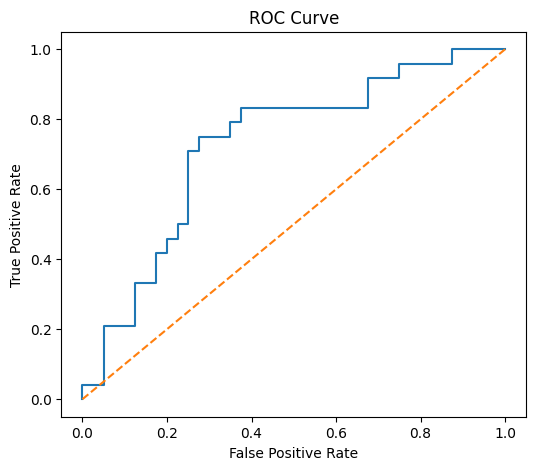

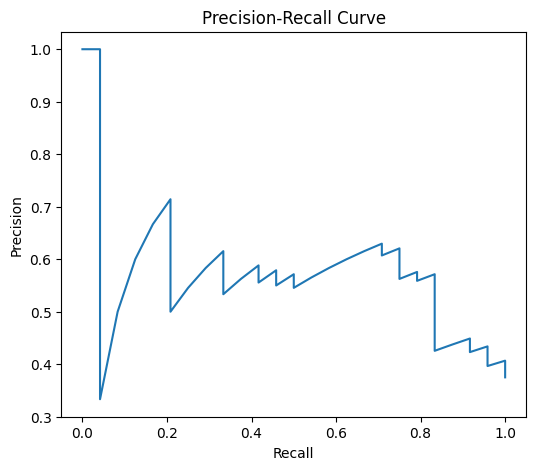


Confusion Matrix:
[[32  8]
 [13 11]]


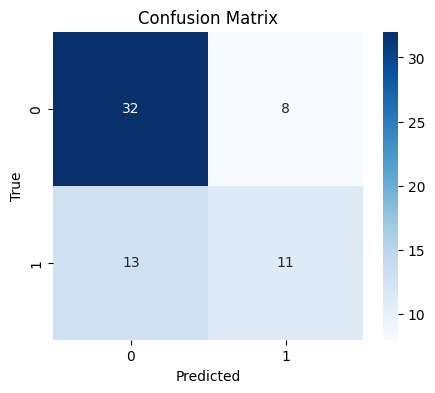


=== Final Test Results ===
auroc: 0.7260
auprc: 0.5840
f1: 0.5116
precision: 0.5789
recall: 0.4583
threshold: 0.5000


In [24]:
set_random_seed(config.SEED)

lr_results_summary = joblib.load("results_summary_logistic_regression.pkl")
rf_results_summary = joblib.load("results_summary_random_forest_large.pkl")
xgboost_results_summary = joblib.load("results_summary.pkl")

xgboost_hyperparams = {
    'mrna_model': XGBClassifier,
    'mrna_model_params': {
        'n_estimators': 600,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 1.0,
    },
    'mrna_threshold': 'median',
    'mrna_max_features': 200,

    'mut_model': XGBClassifier,
    'mut_model_params': {
        'n_estimators': 600,
        'max_depth': 6,
        'learning_rate': 0.05,
    },
    'mut_threshold': 'median',
    'mut_max_features': 50,

    # downstream network
    'hidden_dim': 64,
    'dropout': 0.2,
    'lr': 0.001,

    # mutation preprocessing settings
    'max_mutation_count': 1,
    'mutation_uniform_thresh': 0.98
}


# Combine validation and test sets for each data type
clinical_combined = pd.concat([clinical_val, clinical_test], axis=0)
mrna_combined = pd.concat([mrna_val, mrna_test], axis=0)
mutation_combined = pd.concat([mutation_val, mutation_test], axis=0)
y_combined = pd.concat([y_val, y_test], axis=0)

# Reset indices to avoid misalignment issues
clinical_combined = clinical_combined.reset_index(drop=True)
mrna_combined = mrna_combined.reset_index(drop=True)
mutation_combined = mutation_combined.reset_index(drop=True)
y_combined = y_combined.reset_index(drop=True)

model, test_metrics, best_t = train_simple(
    clinical_train, mrna_train, mutation_train, y_train,
    clinical_combined, mrna_combined, mutation_combined, y_combined,
    xgboost_hyperparams, num_epochs=150, threshold=0.5
)

print("\n=== Final Test Results ===")
for metric, value in test_metrics.items():
    print(f"{metric}: {value:.4f}")


In [25]:
test_loader = to_loader(clinical_test, mrna_test, mutation_test, y_test)

model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        clin = clin.to(device, non_blocking=True)
        mrna = mrna.to(device, non_blocking=True)
        mut = mut.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
auprc = average_precision_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# --- Precision–Recall Curve ---
precisions, recalls, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.tight_layout()
plt.show()

print(average_precision_score(all_labels, all_probs))

                  SUBTYPE CANCER_TYPE_ACRONYM  \
TCGA-A5-A2K3     UCEC_MSI                UCEC   
TCGA-AX-A05W  UCEC_CN_LOW                UCEC   
TCGA-AJ-A3I9  UCEC_CN_LOW                UCEC   
TCGA-AJ-A3BG     UCEC_MSI                UCEC   
TCGA-D1-A168  UCEC_CN_LOW                UCEC   

                                  OTHER_PATIENT_ID     SEX DAYS_LAST_FOLLOWUP  \
TCGA-A5-A2K3  C3096984-BD11-44A0-8EE0-47F07AD04D81  Female               2012   
TCGA-AX-A05W  87e44856-eb9a-475f-96b1-047b7f77b0da  Female               2450   
TCGA-AJ-A3I9  E5D64754-15E8-494E-B7F7-25CF2819FE4C  Female                 39   
TCGA-AJ-A3BG  77ED36AD-222F-4693-8668-0ECF9073D6E8  Female                550   
TCGA-D1-A168  41893e97-7e90-4b03-b738-260f288ade4c  Female               1098   

                           ETHNICITY FORM_COMPLETION_DATE  \
TCGA-A5-A2K3  Not Hispanic Or Latino              10/4/11   
TCGA-AX-A05W  Not Hispanic Or Latino              5/23/11   
TCGA-AJ-A3I9  Not Hispanic Or Latin

ValueError: could not convert string to float: 'UCEC_MSI'